# Overview
based on the methodology in quick_test_v2 but with longer time windows

## WARNING
This is very much a WIP and some vibe-coded slop. Mostly to test a few assumptions. What was ACTUALLY coded is in quick_test_v1

In [1]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import json
from tqdm import tqdm

# API libraries
from newsapi import NewsApiClient
import requests

# NLP libraries
from sentence_transformers import SentenceTransformer

# ML Libraries
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Other libraries
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt

/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def fetch_news_data(start_date: str, end_date: str, language: str, keywords: str, source: str, api_key: str) -> pd.DataFrame:
    """
    Fetch news articles from NewsAPI.org with flexible keywords.
    
    Parameters:
        start_date : Start date in format 'YYYY-MM-DD'
        end_date : End date in format 'YYYY-MM-DD'
        language : Language of the news articles (str)
        keywords : Search keywords (str)
        source : List of sources (str)
        api_key : str
    
    Returns:
        DataFrame with columns: 'publishedAt', 'title', 'source', 'url'
    """
    
    # Initialisation
    newsapi = NewsApiClient(api_key=api_key)
    #SOURCES = 'bild, der-tagesspiegel,die-zeit,focus,handelsblatt,spiegel-online,wirtschafts-woche'
    
    # Calculate date ranges to fetch in weekly increments (data limits)
    end_date = datetime.strptime(end_date, '%Y-%m-%d')
    start_date = datetime.strptime(start_date, '%Y-%m-%d')
    all_articles = []

    total_days = (end_date - start_date).days
    num_periods = (total_days // 7) + (1 if total_days % 7 > 0 else 0)

    # Loop for fetching data
    for period in range(num_periods):
        
        to_date = end_date - timedelta(days=period * 7)
        from_date = to_date - timedelta(days=7)
        from_str = from_date.strftime('%Y-%m-%d')
        to_str = to_date.strftime('%Y-%m-%d')

        articles_period = newsapi.get_everything(
            q=keywords,
            sources=source,
            language=language,
            sort_by='relevancy',
            from_param=from_str,
            to=to_str,
            page_size=100
        )
        
        all_articles.extend(articles_period['articles'])

    # Conversion to DataFrame
    news_df = pd.DataFrame([
        {
            'publishedAt': article['publishedAt'],
            'title': article.get('title', ''),
            'source': article['source']['name'],
        }
        for article in all_articles
    ])

    # Date Conversion, Sorting and Duplicate Removal + Validation Check
    news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt'])
    news_df = news_df.sort_values('publishedAt')
    news_df = news_df.drop_duplicates(subset=['title'], keep='first')

    if news_df.empty:
        print("Warning: No articles fetched!")
        return pd.DataFrame(columns=['publishedAt', 'title', 'source'])
    else:
        print(f"Successfully fetched {len(news_df)} articles")
        return news_df

In [3]:
# Define our search parameters
start_date = '2021-01-01'
end_date = '2025-10-01'
language = 'de'
keywords = (
    '"Energie" OR "Strom" OR "Energiewende" OR "Kraftwerk" OR '
    '"Erneuerbare" OR "Stromversorgung" OR "Energieversorgung" OR '
    '"Stromerzeugung" OR "Energieerzeugung"OR "Inflation"'
)
source = 'bild, der-tagesspiegel,die-zeit,focus,handelsblatt,spiegel-online,wirtschafts-woche'

load_dotenv()
NEWS_API_KEY = os.getenv('NEWSAPIORG_KEY')


# Fetch the data
news_df = fetch_news_data(start_date, end_date, language, keywords, source, NEWS_API_KEY)

Successfully fetched 16713 articles


New implmentation of Energy news, pulling it directly from the API and subtituting spot price for auction price. No backtest possible, in the future, will work with CSV after pre-processing

In [4]:
def fetch_energy_charts_data(start_date: str, end_date: str, bidding_zone: str = 'DE-LU') -> pd.DataFrame:
    """
    Fetch hourly price and power generation data from Energy Charts API.
    
    Parameters:
    -----------
    start_date : str
        Start date in format 'YYYY-MM-DD'
    end_date : str
        End date in format 'YYYY-MM-DD'
    bidding_zone : str
        Bidding zone code (default: 'DE-LU' for Germany/Luxembourg)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with datetime index and columns: 'price', 'total_power'
    """
    base_url = "https://api.energy-charts.info"
    
    # Fetch price data (day-ahead spot price)
    print(f"Fetching price data from {start_date} to {end_date} for bidding zone {bidding_zone}...")
    price_url = f"{base_url}/price"
    price_params = {
        'bzn': bidding_zone,  # Bidding zone (DE-LU for Germany/Luxembourg)
        'start': start_date,
        'end': end_date
    }
    
    try:
        price_response = requests.get(price_url, params=price_params, timeout=30)
        price_response.raise_for_status()
        price_data = price_response.json()
        print(f"Price data received successfully")
        print(f"Response keys: {list(price_data.keys())}")
    except requests.exceptions.RequestException as e:
        print(f"Error fetching price data: {e}")
        print(f"URL: {price_url}")
        print(f"Params: {price_params}")
        raise
    
    # Fetch total power generation data
    print(f"Fetching power generation data from {start_date} to {end_date}...")
    power_url = f"{base_url}/total_power"
    power_params = {
        'country': 'de',  # Only available for Germany according to docs
        'start': start_date,
        'end': end_date
    }
    
    try:
        power_response = requests.get(power_url, params=power_params, timeout=30)
        power_response.raise_for_status()
        power_data = power_response.json()
        print(f"Power data received successfully")
        print(f"Response keys: {list(power_data.keys())}")
    except requests.exceptions.RequestException as e:
        print(f"Error fetching power data: {e}")
        print(f"URL: {power_url}")
        print(f"Params: {power_params}")
        raise
    
    # Parse price data
    if 'unix_seconds' in price_data and 'price' in price_data:
        price_timestamps = pd.to_datetime(price_data['unix_seconds'], unit='s')
        prices = price_data['price']
        price_df = pd.DataFrame({'price': prices}, index=price_timestamps)
        print(f"Price data parsed: {len(price_df)} records")
    else:
        print(f"Available keys in price_data: {price_data.keys()}")
        raise ValueError("Unexpected price data structure")
    
    # Parse power data - aggregate all production types
    if 'unix_seconds' in power_data and 'production_types' in power_data:
        power_timestamps = pd.to_datetime(power_data['unix_seconds'], unit='s')
        print(f"Power timestamps: {len(power_timestamps)} records")
        print(f"Production types: {len(power_data['production_types'])} types")
        
        # Sum all production types to get total power
        total_power = np.zeros(len(power_timestamps))
        for i, production_type in enumerate(power_data['production_types']):
            print(f"Processing production type {i+1}: {production_type['name']} ({len(production_type['data'])} values)")
            try:
                production_values = np.array(production_type['data'])
                total_power += production_values
            except Exception as e:
                print(f"Error processing production type {production_type['name']}: {e}")
                continue
        
        power_df = pd.DataFrame({'total_power': total_power}, index=power_timestamps)
        print(f"Power data parsed: {len(power_df)} records")
    else:
        print(f"Available keys in power_data: {power_data.keys()}")
        raise ValueError("Unexpected power data structure")
    
    # Merge the two datasets
    energy_df = price_df.join(power_df, how='outer')
    
    print(f"Energy data fetched: {len(energy_df)} records")
    print(f"Date range: {energy_df.index.min()} to {energy_df.index.max()}")
    
    return energy_df

# Fetch years of data
start_date = '2021-01-01'
end_date = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')

energy_df = fetch_energy_charts_data(start_date, end_date)
energy_df.head()


Fetching price data from 2021-01-01 to 2025-10-27 for bidding zone DE-LU...
Price data received successfully
Response keys: ['license_info', 'unix_seconds', 'price', 'unit', 'deprecated']
Fetching power generation data from 2021-01-01 to 2025-10-27...
Power data received successfully
Response keys: ['unix_seconds', 'production_types', 'deprecated']
Price data parsed: 44211 records
Power timestamps: 169056 records
Production types: 22 types
Processing production type 1: Hydro pumped storage consumption (169056 values)
Processing production type 2: Cross border electricity trading (169056 values)
Processing production type 3: Nuclear (169056 values)
Error processing production type Nuclear: Cannot cast ufunc 'add' output from dtype('O') to dtype('float64') with casting rule 'same_kind'
Processing production type 4: Hydro Run-of-River (169056 values)
Processing production type 5: Biomass (169056 values)
Processing production type 6: Fossil brown coal / lignite (169056 values)
Processing p

,price,total_power
2020-12-31 23:00:00,50.87,130449.2
2020-12-31 23:15:00,NaN,129893.5
2020-12-31 23:30:00,NaN,128824.1
2020-12-31 23:45:00,NaN,128068.3
2021-01-01 00:00:00,48.19,126289.1


Feature Engineering section here

In [5]:
master_df = energy_df.copy()

# Temporal Features
master_df['hour'] = master_df.index.hour
master_df['day_of_week'] = master_df.index.dayofweek
master_df['day_of_year'] = master_df.index.dayofyear
master_df['month'] = master_df.index.month
master_df['week_of_year'] = master_df.index.isocalendar().week.values

# Lagged features of price and total_power for 24h and 168h
master_df['price_lag24'] = master_df['price'].shift(24)
master_df['total_power_lag24'] = master_df['total_power'].shift(24)
master_df['price_lag168'] = master_df['price'].shift(168)
master_df['total_power_lag168'] = master_df['total_power'].shift(168)
master_df.tail(10)

,price,total_power,hour,day_of_week,day_of_year,month,week_of_year,price_lag24,total_power_lag24,price_lag168,total_power_lag168
2025-10-27 20:30:00,72.52,143521.7,20,0,300,10,44,87.30,162522.0,0.10,88738.8
2025-10-27 20:45:00,63.01,140212.2,20,0,300,10,44,99.45,162150.1,0.00,88894.6
2025-10-27 21:00:00,83.93,140710.1,21,0,300,10,44,87.30,162945.4,0.20,88155.9
2025-10-27 21:15:00,76.05,137770.3,21,0,300,10,44,94.73,164164.4,0.10,88196.6
2025-10-27 21:30:00,76.19,134659.8,21,0,300,10,44,103.89,164713.2,0.10,87400.2
2025-10-27 21:45:00,61.75,131476.4,21,0,300,10,44,111.01,165261.3,0.01,87436.8
2025-10-27 22:00:00,80.00,127467.1,22,0,300,10,44,100.52,166676.6,0.12,86662.2
2025-10-27 22:15:00,68.02,124137.5,22,0,300,10,44,106.68,168902.5,0.10,87379.8
2025-10-27 22:30:00,55.61,120947.8,22,0,300,10,44,113.06,171470.3,0.10,88370.4
2025-10-27 22:45:00,46.07,118248.9,22,0,300,10,44,122.58,170803.4,0.10,87925.3


In [6]:
def compute_time_decayed_embedding(target_time, news_df, decay_lambda=0.1, lookback_hours=168):
    """
    Compute time-weighted average of news embeddings for a specific quarter_hour.
    
    Parameters:
        target_time (datetime): The timestamp we're predicting for
        news_df (DataFrame): News articles with 'publishedAt' and 'embedding' columns
        decay_lambda (float): Decay rate
        lookback_quarter_hours (int): Maximum quarter_hours to look back for news
    
    Returns:
        np.array: Time-weighted average embedding
    """

    news_times = news_df['publishedAt'].dt.tz_localize(None)
    target_time = target_time.tz_localize(None)



    time_window_start = target_time - pd.Timedelta(hours=lookback_hours)

    relevant_news = news_df[
        (news_times < target_time) & 
        (news_times >= time_window_start)
    ]
    
    if len(relevant_news) == 0:
        return np.zeros(384)
    
    hours_ago = (target_time - relevant_news['publishedAt'].dt.tz_localize(None)).values / pd.Timedelta(hours=1)
    weights = np.exp(-decay_lambda * hours_ago)
    weights = weights / weights.sum()
    
    embeddings_array = np.stack(relevant_news['embedding'].values)
    weighted_embedding = (embeddings_array.T @ weights).T
    
    return weighted_embedding


In [7]:
# Embed each article
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

article_embeddings = model.encode(
    news_df['title'].tolist(), 
    show_progress_bar=True, 
    batch_size=32
)

news_df['embedding'] = list(article_embeddings)

# Compute time-decayed embedding for each hour in master_df
time_decayed_embeddings = []

for timestamp in tqdm(master_df.index, desc="Processing hours"):
    
    embedding = compute_time_decayed_embedding(
        timestamp, 
        news_df,
        decay_lambda=0.1,
        lookback_hours=168
    )
    time_decayed_embeddings.append(embedding)

time_decayed_embeddings = np.array(time_decayed_embeddings)

# Keep the original embedding dimensions (no PCA)
embedding_dim = time_decayed_embeddings.shape[1]
embedding_columns = [f'news_embed_{i}' for i in range(embedding_dim)]

news_embeddings_df = pd.DataFrame(
    time_decayed_embeddings,
    index=master_df.index,
    columns=embedding_columns
)

master_df = pd.concat([master_df, news_embeddings_df], axis=1)

master_df.tail(10)

Processing hours: 100%|██████████| 169056/169056 [01:07<00:00, 2493.01it/s]


,price,total_power,hour,day_of_week,day_of_year,month,week_of_year,price_lag24,total_power_lag24,price_lag168,...,news_embed_374,news_embed_375,news_embed_376,news_embed_377,news_embed_378,news_embed_379,news_embed_380,news_embed_381,news_embed_382,news_embed_383
2025-10-27 20:30:00,72.52,143521.7,20,0,300,10,44,87.30,162522.0,0.10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-10-27 20:45:00,63.01,140212.2,20,0,300,10,44,99.45,162150.1,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-10-27 21:00:00,83.93,140710.1,21,0,300,10,44,87.30,162945.4,0.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-10-27 21:15:00,76.05,137770.3,21,0,300,10,44,94.73,164164.4,0.10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-10-27 21:30:00,76.19,134659.8,21,0,300,10,44,103.89,164713.2,0.10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-10-27 21:45:00,61.75,131476.4,21,0,300,10,44,111.01,165261.3,0.01,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-10-27 22:00:00,80.00,127467.1,22,0,300,10,44,100.52,166676.6,0.12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-10-27 22:15:00,68.02,124137.5,22,0,300,10,44,106.68,168902.5,0.10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-10-27 22:30:00,55.61,120947.8,22,0,300,10,44,113.06,171470.3,0.10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-10-27 22:45:00,46.07,118248.9,22,0,300,10,44,122.58,170803.4,0.10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Model training here

In [11]:
# Set target variable and shift it by 24 hours
y = master_df['price'].shift(-24)

baseline_features = [
    'total_power',
    'hour', 'day_of_week', 'day_of_year', 'month', 'week_of_year',
    'price_lag24', 'total_power_lag24', 'price_lag168', 'total_power_lag168'
]

news_embedding_features = [col for col in master_df.columns if col.startswith('news_embed_')]
advanced_features = baseline_features + news_embedding_features

X_baseline = master_df[baseline_features]
X_advanced = master_df[advanced_features]

# Remove rows where y is NaN (last 24 rows since we shifted by -24)
valid_indices = ~y.isna()
X_baseline = X_baseline[valid_indices]
X_advanced = X_advanced[valid_indices]
y = y[valid_indices]

print(f"After removing NaN targets:")
print(f"X_baseline shape: {X_baseline.shape}")
print(f"X_advanced shape: {X_advanced.shape}")
print(f"y shape: {y.shape}")

# Split the data
split_idx = int(len(y) * 0.8)

X_train_baseline, X_test_baseline = X_baseline[:split_idx], X_baseline[split_idx:]
X_train_advanced, X_test_advanced = X_advanced[:split_idx], X_advanced[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\nTraining set shapes:")
print(f"X_train_baseline: {X_train_baseline.shape}")
print(f"X_train_advanced: {X_train_advanced.shape}")
print(f"y_train: {y_train.shape}")

print(f"\nTest set shapes:")
print(f"X_test_baseline: {X_test_baseline.shape}")
print(f"X_test_advanced: {X_test_advanced.shape}")
print(f"y_test: {y_test.shape}")

After removing NaN targets:
X_baseline shape: (44205, 10)
X_advanced shape: (44205, 394)
y shape: (44205,)

Training set shapes:
X_train_baseline: (35364, 10)
X_train_advanced: (35364, 394)
y_train: (35364,)

Test set shapes:
X_test_baseline: (8841, 10)
X_test_advanced: (8841, 394)
y_test: (8841,)


In [12]:
# Check for NaN values in features and handle them
print("Checking for NaN values in features...")
print(f"NaN values in X_train_baseline: {X_train_baseline.isna().sum().sum()}")
print(f"NaN values in X_train_advanced: {X_train_advanced.isna().sum().sum()}")
print(f"NaN values in y_train: {y_train.isna().sum()}")

# Fill NaN values with forward fill for lagged features, and median for others
X_train_baseline = X_train_baseline.fillna(method='ffill').fillna(method='bfill')
X_train_advanced = X_train_advanced.fillna(method='ffill').fillna(method='bfill')

# Also handle test sets
X_test_baseline = X_test_baseline.fillna(method='ffill').fillna(method='bfill')
X_test_advanced = X_test_advanced.fillna(method='ffill').fillna(method='bfill')

print(f"\nAfter filling NaN values:")
print(f"NaN values in X_train_baseline: {X_train_baseline.isna().sum().sum()}")
print(f"NaN values in X_train_advanced: {X_train_advanced.isna().sum().sum()}")

# Train the models
baseline_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
baseline_model.fit(X_train_baseline, y_train)

advanced_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
advanced_model.fit(X_train_advanced, y_train)

print("Models trained successfully!")

Checking for NaN values in features...
NaN values in X_train_baseline: 96
NaN values in X_train_advanced: 96
NaN values in y_train: 0


/var/folders/g9/0v3_zgv50lx0t6nwqgvc6d080000gn/T/ipykernel_54808/1738685816.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_train_baseline = X_train_baseline.fillna(method='ffill').fillna(method='bfill')
/var/folders/g9/0v3_zgv50lx0t6nwqgvc6d080000gn/T/ipykernel_54808/1738685816.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_train_advanced = X_train_advanced.fillna(method='ffill').fillna(method='bfill')
/var/folders/g9/0v3_zgv50lx0t6nwqgvc6d080000gn/T/ipykernel_54808/1738685816.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_test_baseline = X_test_baseline.fillna(method='ffill').fillna(method='bfill')
/var/folders/g9/0v3_zgv50lx0t6nwqgvc6d080000gn/T/ipykernel_54808/1738685816.py:13: FutureWarnin


After filling NaN values:
NaN values in X_train_baseline: 0
NaN values in X_train_advanced: 0
Models trained successfully!


Model Evaluation here

In [13]:
y_pred_baseline = baseline_model.predict(X_test_baseline)
y_pred_advanced = advanced_model.predict(X_test_advanced)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

advanced_mae = mean_absolute_error(y_test, y_pred_advanced)
advanced_rmse = np.sqrt(mean_squared_error(y_test, y_pred_advanced))

print(f"Baseline Model - MAE: {baseline_mae:.4f}, RMSE: {baseline_rmse:.4f}")
print(f"Advanced Model - MAE: {advanced_mae:.4f}, RMSE: {advanced_rmse:.4f}")

Baseline Model - MAE: 24.2837, RMSE: 35.7685
Advanced Model - MAE: 25.5941, RMSE: 36.7801


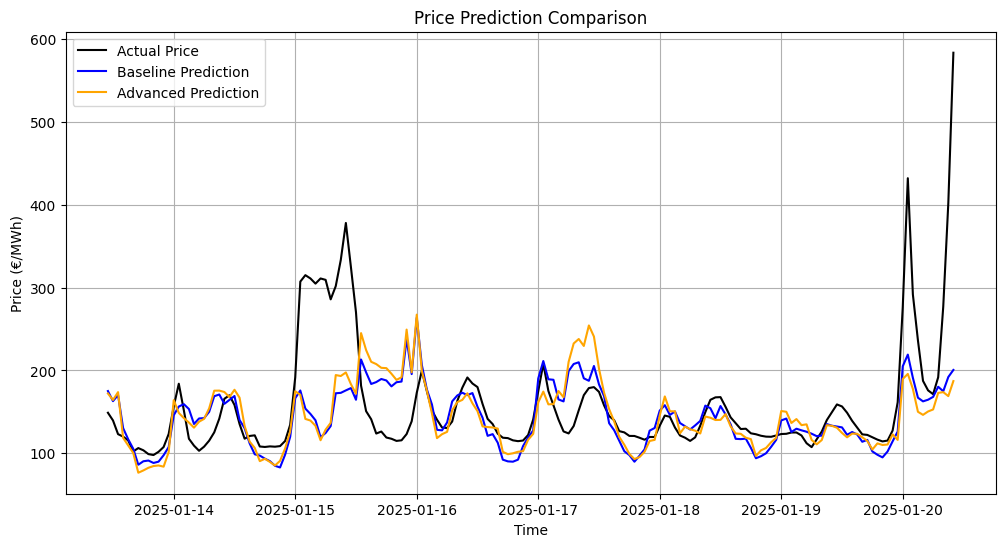

In [14]:
last_week_length = 24 * 7

fig, ax = plt.subplots(figsize=(12, 6))

time_index = y_test.index

ax.plot(time_index[:last_week_length], y_test[:last_week_length], label='Actual Price', color='black')
ax.plot(time_index[:last_week_length], y_pred_baseline[:last_week_length], label='Baseline Prediction', color='blue')
ax.plot(time_index[:last_week_length], y_pred_advanced[:last_week_length], label='Advanced Prediction', color='orange')

ax.set_xlabel('Time')
ax.set_ylabel('Price (€/MWh)')
ax.set_title('Price Prediction Comparison')
ax.legend()
ax.grid(True)

plt.show()

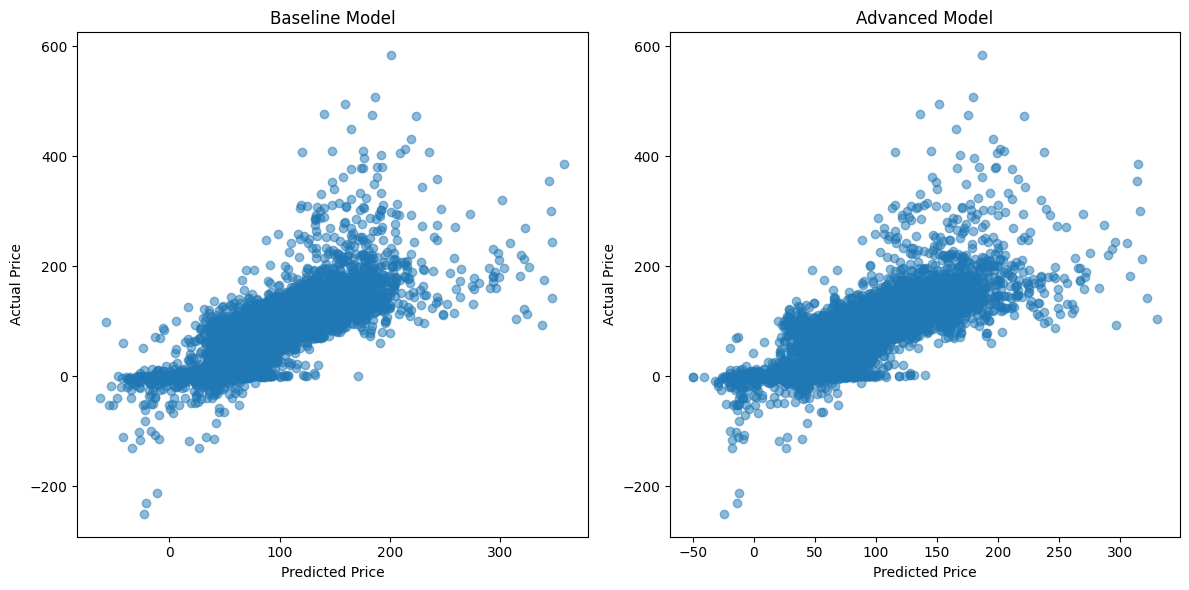

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].scatter(y_pred_baseline, y_test, alpha=0.5)
ax[0].set_xlabel('Predicted Price')
ax[0].set_ylabel('Actual Price')
ax[0].set_title('Baseline Model')

ax[1].scatter(y_pred_advanced, y_test, alpha=0.5)
ax[1].set_xlabel('Predicted Price')
ax[1].set_ylabel('Actual Price')
ax[1].set_title('Advanced Model')

plt.tight_layout()
plt.show()

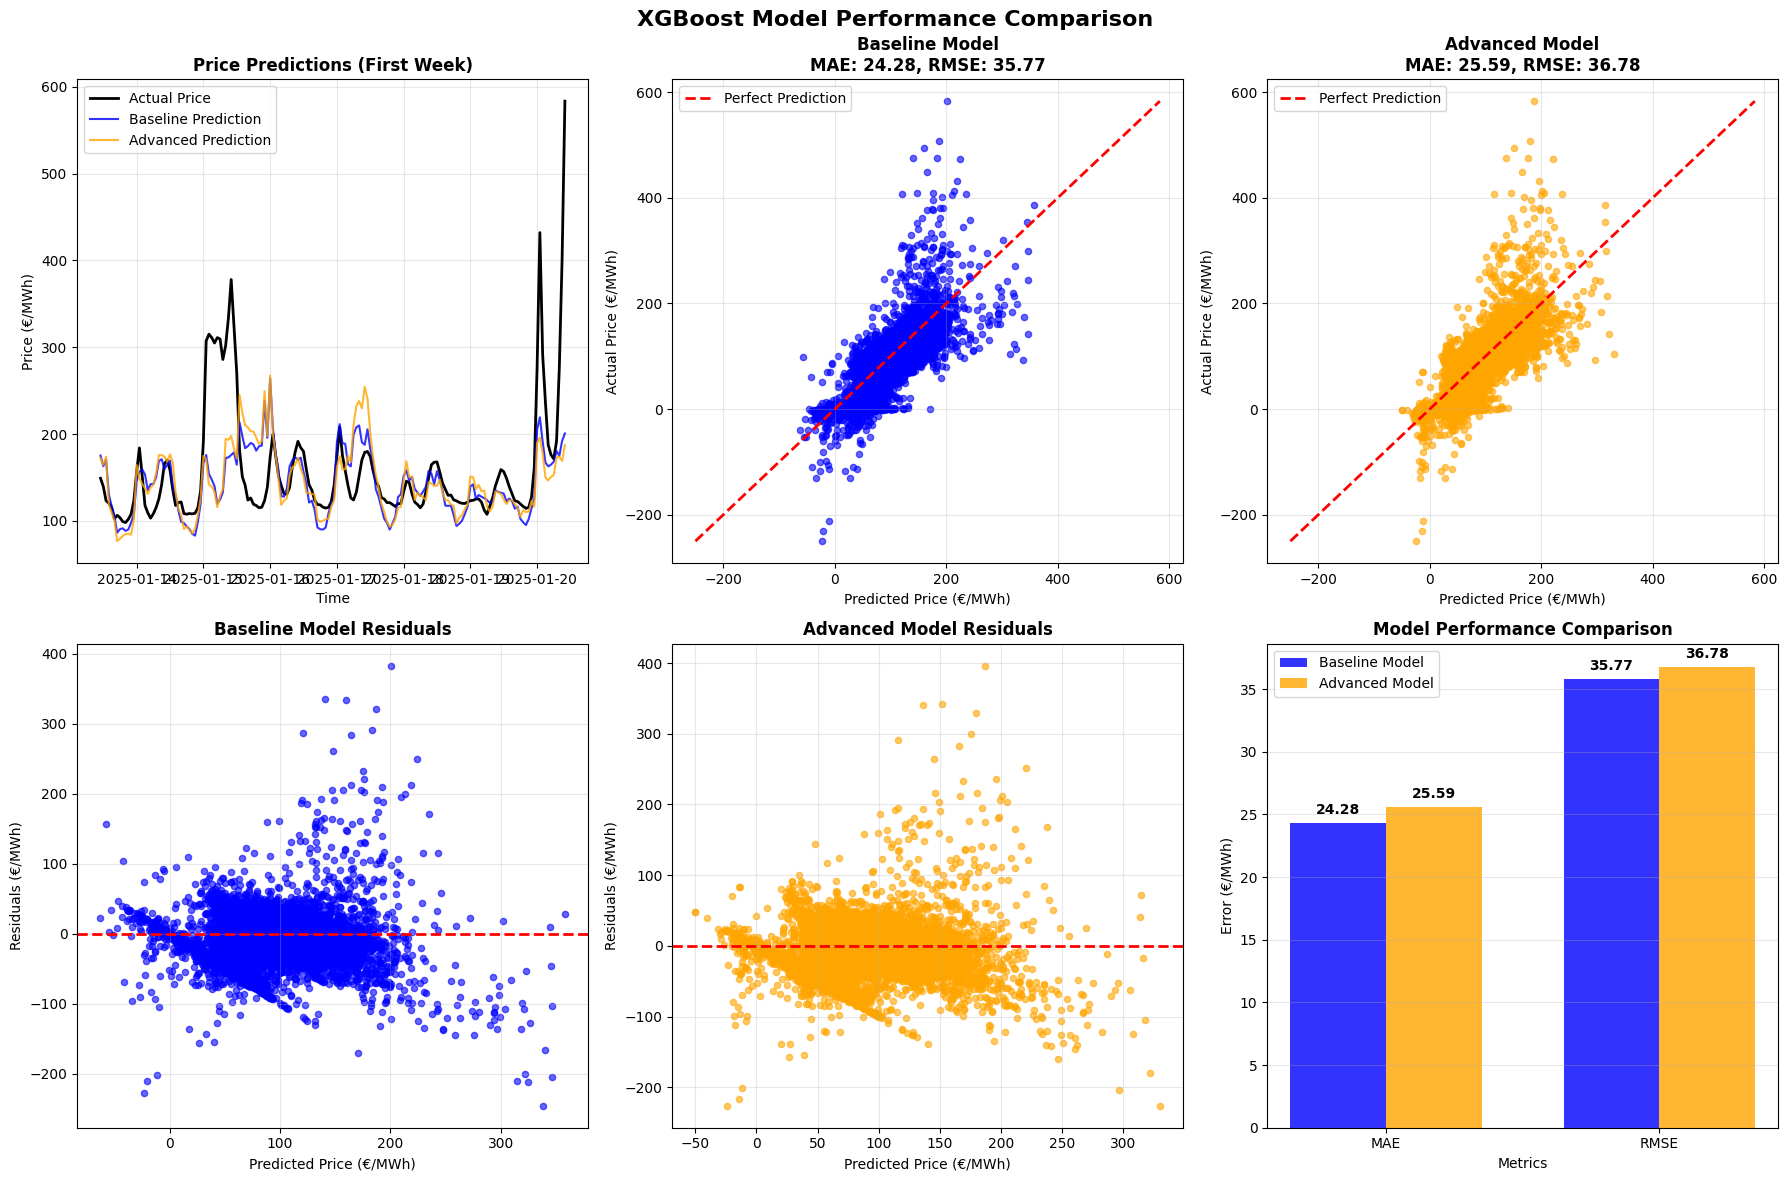


MODEL PERFORMANCE SUMMARY
Baseline Model:
  - MAE:  24.2837 €/MWh
  - RMSE: 35.7685 €/MWh
  - Features: 10

Advanced Model:
  - MAE:  25.5941 €/MWh
  - RMSE: 36.7801 €/MWh
  - Features: 394

Improvement with News Features:
  - MAE:  -5.40% better
  - RMSE: -2.83% better


In [16]:
# Comprehensive model performance visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('XGBoost Model Performance Comparison', fontsize=16, fontweight='bold')

# Plot 1: Time series comparison (first week)
last_week_length = 24 * 7
time_index = y_test.index

axes[0, 0].plot(time_index[:last_week_length], y_test[:last_week_length], 
                label='Actual Price', color='black', linewidth=2)
axes[0, 0].plot(time_index[:last_week_length], y_pred_baseline[:last_week_length], 
                label='Baseline Prediction', color='blue', alpha=0.8)
axes[0, 0].plot(time_index[:last_week_length], y_pred_advanced[:last_week_length], 
                label='Advanced Prediction', color='orange', alpha=0.8)
axes[0, 0].set_title('Price Predictions (First Week)', fontweight='bold')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Price (€/MWh)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Scatter plot - Baseline Model
axes[0, 1].scatter(y_pred_baseline, y_test, alpha=0.6, color='blue', s=20)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Predicted Price (€/MWh)')
axes[0, 1].set_ylabel('Actual Price (€/MWh)')
axes[0, 1].set_title(f'Baseline Model\nMAE: {baseline_mae:.2f}, RMSE: {baseline_rmse:.2f}', 
                     fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Scatter plot - Advanced Model
axes[0, 2].scatter(y_pred_advanced, y_test, alpha=0.6, color='orange', s=20)
axes[0, 2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 2].set_xlabel('Predicted Price (€/MWh)')
axes[0, 2].set_ylabel('Actual Price (€/MWh)')
axes[0, 2].set_title(f'Advanced Model\nMAE: {advanced_mae:.2f}, RMSE: {advanced_rmse:.2f}', 
                     fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Residuals - Baseline Model
residuals_baseline = y_test - y_pred_baseline
axes[1, 0].scatter(y_pred_baseline, residuals_baseline, alpha=0.6, color='blue', s=20)
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Price (€/MWh)')
axes[1, 0].set_ylabel('Residuals (€/MWh)')
axes[1, 0].set_title('Baseline Model Residuals', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Residuals - Advanced Model
residuals_advanced = y_test - y_pred_advanced
axes[1, 1].scatter(y_pred_advanced, residuals_advanced, alpha=0.6, color='orange', s=20)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted Price (€/MWh)')
axes[1, 1].set_ylabel('Residuals (€/MWh)')
axes[1, 1].set_title('Advanced Model Residuals', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Model comparison metrics
metrics = ['MAE', 'RMSE']
baseline_metrics = [baseline_mae, baseline_rmse]
advanced_metrics = [advanced_mae, advanced_rmse]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1, 2].bar(x - width/2, baseline_metrics, width, label='Baseline Model', 
                       color='blue', alpha=0.8)
bars2 = axes[1, 2].bar(x + width/2, advanced_metrics, width, label='Advanced Model', 
                       color='orange', alpha=0.8)

axes[1, 2].set_xlabel('Metrics')
axes[1, 2].set_ylabel('Error (€/MWh)')
axes[1, 2].set_title('Model Performance Comparison', fontweight='bold')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(metrics)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')
    
for bar in bars2:
    height = bar.get_height()
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(f"Baseline Model:")
print(f"  - MAE:  {baseline_mae:.4f} €/MWh")
print(f"  - RMSE: {baseline_rmse:.4f} €/MWh")
print(f"  - Features: {len(baseline_features)}")
print()
print(f"Advanced Model:")
print(f"  - MAE:  {advanced_mae:.4f} €/MWh")
print(f"  - RMSE: {advanced_rmse:.4f} €/MWh")
print(f"  - Features: {len(advanced_features)}")
print()
improvement_mae = ((baseline_mae - advanced_mae) / baseline_mae) * 100
improvement_rmse = ((baseline_rmse - advanced_rmse) / baseline_rmse) * 100
print(f"Improvement with News Features:")
print(f"  - MAE:  {improvement_mae:.2f}% better")
print(f"  - RMSE: {improvement_rmse:.2f}% better")
print("="*60)
